# Video: Matrix Completion with Singular Value Decomposition

In this video, you will see an example of using singular value decomposition to fill in missing data in matrix completion problems.

[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week13/video_matrix_completion_with_singular_value_decomposition.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week13/video_matrix_completion_with_singular_value_decomposition.ipynb)



Script: (faculty on screen)
* Matrix completion is a useful technique to fill in the blanks when you believe the matrix has structure in its entries.
* The most common example is when the matrix is assumed to have low rank structure.

## Matrix Completion

$$\begin{array}{rcl} \begin{bmatrix} 1 & 2 & 3 & ? \\ 5 & ? & 7 & 8 \\ ? & ? & 11 & 12 \end{bmatrix} & = & \begin{bmatrix} 0 & 1 & 2 & 3 \\ 1 & 1 & 1 & 1 \end{bmatrix} \begin{bmatrix} 1 & 1 \\ 1 & 5 \\ 1 & 9 \end{bmatrix} \end{array} $$

Script:
* Here's an example.
* Given the matrix on the left, can we express it as a low rank product?
* Multiplying the two matrices on the right will match all the values on the left, and suggest values where they are missing.

## An Easy Rank Two Example


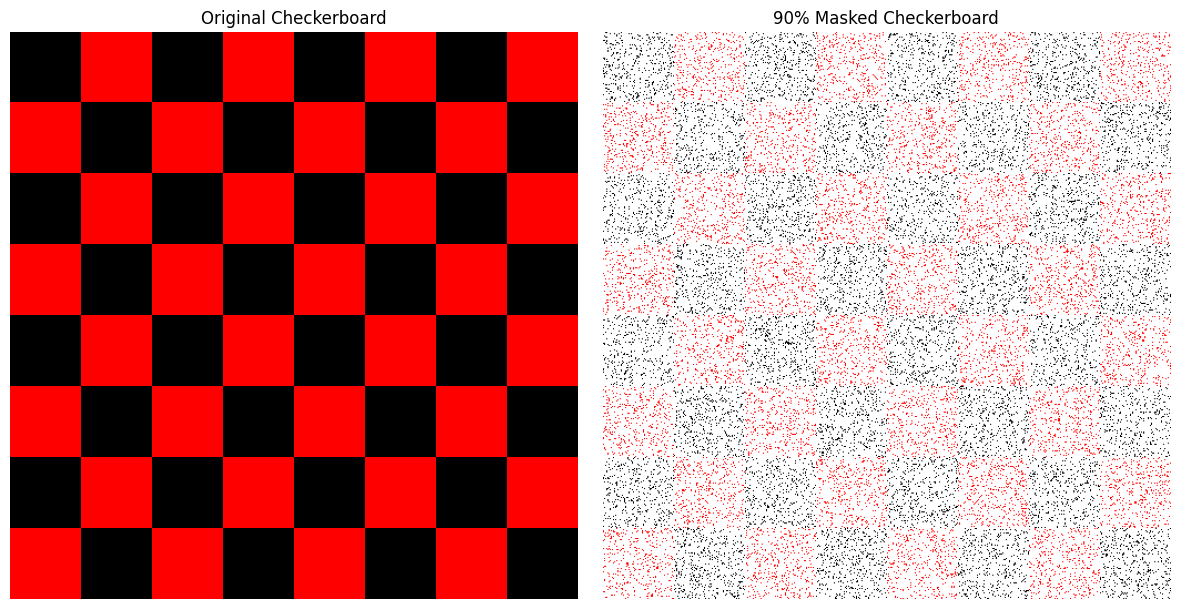

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Create a 512x512 black and red checkerboard
size = 512
num_squares = 8
square_size = size // num_squares

# Create a basic 8x8 checkerboard of indices (0 and 1)
x = np.arange(num_squares)
y = np.arange(num_squares)
xx, yy = np.meshgrid(x, y)
# Logic: if sum of indices is even, it's one color; if odd, another.
indices = (xx + yy) % 2

# Upscale the indices to 512x512
full_indices = np.repeat(np.repeat(indices, square_size, axis=0), square_size, axis=1)

# Map indices to colors: 0 -> Black [0,0,0], 1 -> Red [1,0,0]
original_chessboard = np.zeros((size, size, 3))
original_chessboard[full_indices == 1] = [1, 0, 0]

# 2. Make a copy with an alpha channel (RGBA)
masked_chessboard = np.zeros((size, size, 4))
masked_chessboard[:, :, :3] = original_chessboard

# 3. Use alpha channel to make 90% of pixels transparent
np.random.seed(42)
# 10% opaque (1.0), 90% transparent (0.0)
alpha_mask = (np.random.rand(size, size) < 0.1).astype(float)
masked_chessboard[:, :, 3] = alpha_mask

# 4. Plot both images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_chessboard)
axes[0].set_title("Original Checkerboard")
axes[0].axis('off')

# imshow blends RGBA with the axes background (usually white)
axes[1].imshow(masked_chessboard)
axes[1].set_title("90% Masked Checkerboard")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Script:
* This checkerboard is an easy example.
* It's easy to argue that it has rank two.
* There are only two distinct rows in the checkerboard.
* There are rows starting with black and rows starting with red.
* On the right, 90% of the pixels are missing.
* Can they be recovered automatically?

## Iterative Matrix Completion Idea

1. Fill in the missing data with the average of the known pixels.
2. Calculate a low rank approximation of the current data.
3. Update the missing data based on the low rank approximation.
4. Repeat steps 2-3...

Script:
* The basic idea of iterative matrix completion is to repeatedly compute low rank approximations and updating the missing data based on the low rank approximations.
* Before this process can start, the missing daa need to be filled in.
* This can be done with a simple approximation like taking the average of the known data.
* Once there are values filled in everywhere, then off-the-shelf low rank approximations can be used like singular value decompositions.
* The low rank approximation then provides better values to fill in the missing data.
* The process repeats until the changes slow or stop.

## Initializing Matrix Completion


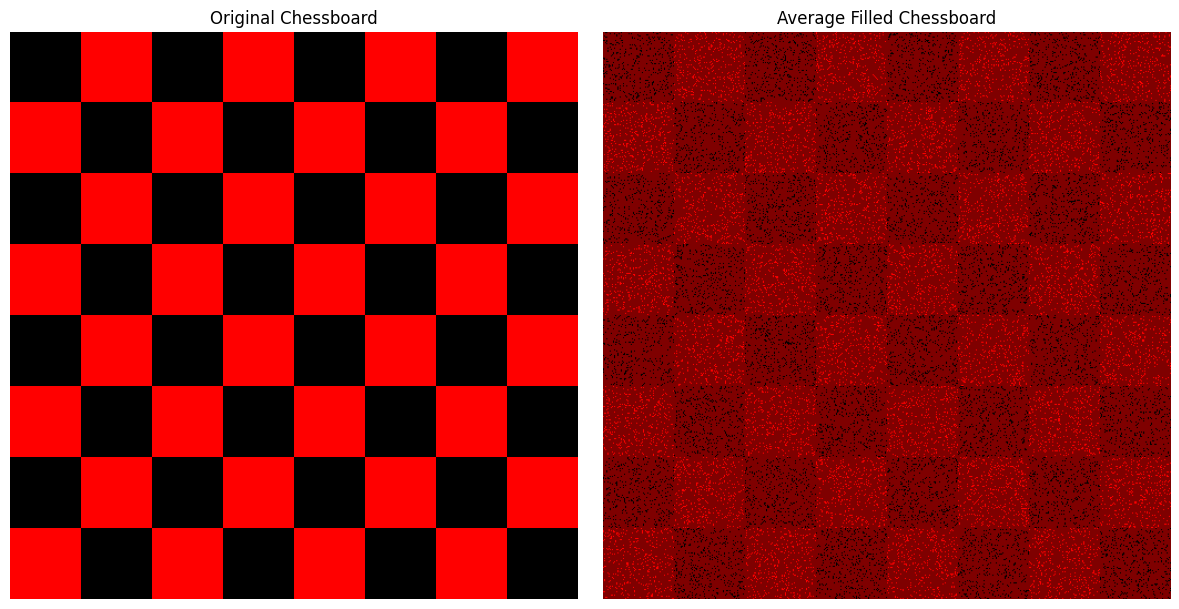

In [ ]:
# 1. Identify observed pixels using the alpha channel (alpha == 1.0)
# Note: alpha_mask has 1.0 for observed, 0.0 for masked/transparent
observed_indices = alpha_mask == 1.0

# 2. Calculate the average color of the unmasked pixels
# We take the mean across the spatial dimensions for RGB channels
avg_color = original_chessboard[observed_indices].mean(axis=0)

# 3. Create the filled chessboard
average_filled_chessboard = original_chessboard.copy()
# Replace masked pixels (alpha == 0.0) with the average color
average_filled_chessboard[alpha_mask == 0.0] = avg_color

# 4. Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_chessboard)
axes[0].set_title("Original Chessboard")
axes[0].axis('off')

axes[1].imshow(average_filled_chessboard)
axes[1].set_title(f"Average Filled Chessboard")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Script:
* Here's the initialization step for the checkerboard.
* You can see that the filled in pixels are a blend of the red and black colors.

## Iterative Matrix Completion Function


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation
from IPython.display import HTML

# Helper function to compute rank-k approximation
def get_rank_k_approx(image, k):
    reconstructed = np.zeros_like(image)
    for i in range(3):  # RGB channels
        u, s, vh = np.linalg.svd(image[:, :, i], full_matrices=False)
        s_k = np.diag(s[:k])
        u_k = u[:, :k]
        vh_k = vh[:k, :]
        reconstructed[:, :, i] = u_k @ s_k @ vh_k
    return np.clip(reconstructed, 0, 1)

def create_and_save_animation(filename, figure, images, **kwargs):
    kwargs.setdefault("blit", True)
    kwargs.setdefault("interval", 1000)
    kwargs.setdefault("repeat_delay", 2000)

    ani = ArtistAnimation(figure, images, **kwargs)

    plt.close() # Prevent static plot from showing

    ani.save(filename, writer='ffmpeg', fps=1)

    return HTML(ani.to_jshtml())

def create_matrix_completion_animation(filename, rank, num_iterations=30):
    # 1. Initialize variables
    approximate_chessboard = [average_filled_chessboard.copy()]
    checkerboard_mask = (alpha_mask == 1.0) # True for unmasked pixels

    # 2. Iterative Updates
    for i in range(num_iterations):
        # Compute rank-k approximation
        current_image = approximate_chessboard[-1]
        rank_k_approx = get_rank_k_approx(current_image, rank)

        # Combine: use original pixels where available, approx where masked
        next_image = rank_k_approx.copy()
        next_image[checkerboard_mask] = original_chessboard[checkerboard_mask]

        approximate_chessboard.append(next_image.copy())

    # 3. Create Video Animation
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis('off')

    ims = []
    for i, img in enumerate(approximate_chessboard):
        title_text = f"Rank {rank} Approximation - Iteration {i}"
        title = ax.text(0.5, 1.05, title_text,
                        size=plt.rcParams["axes.titlesize"],
                        ha="center", transform=ax.transAxes)
        im = ax.imshow(img, animated=True)
        ims.append([im, title])

    return create_and_save_animation(filename, fig, ims)

# Demo with rank 2
create_matrix_completion_animation("checkerboard-2.mp4", rank=2, num_iterations=30)

Output hidden; open in https://colab.research.google.com to view.

Script:
* Now you can see the iterative update process.
* It starts messy, but with each iteration, it becomes clearer.
* Around 25 iterations, it looks pretty good and does not change much any more.

## Iterative Matrix Completion with Rank Ten


In [ ]:
create_matrix_completion_animation("checkerboard-10.mp4", rank=10, num_iterations=30)

Output hidden; open in https://colab.research.google.com to view.

Script:
* If we rerun the process using rank 10 approximations, then the changes stop after about 10 iterations, and there are more visible errors left.
* This is because the extra rank effectively gave more information capacity to fit the noise too.

## A Harder Example


In [ ]:
import numpy as np
import pandas as pd

people = [
    "U1",
    "U2",
    "U3",
    "U4",
    "U5",
    "U6",
    "U7",
    "U8",
    "U9",
    "U10",
]

songs = [
    "Born to Run",
    "Sweet Child O' Mine",
    "Smells Like Teen Spirit",
    "American Idiot",
    "Everlong",
    "Hotel California",
    "Seven Nation Army",
    "Mr. Brightside",
    "Under the Bridge",
    "Don't Stop Believin'",
    "Dynamite",
    "Butter",
    "Gangnam Style",
    "How You Like That",
    "DDU-DU DDU-DU",
    "Kill This Love",
    "Gee",
    "CHEER UP",
    "I AM THE BEST",
    "LOVE SCENARIO",
]

# Rows are people.
# Columns are songs.
# Missing ratings are represented by np.nan.
ratings_raw = np.array([
    [5, 5, 5, 4, 5, 4, np.nan, 4, 5, 4, 2, np.nan, 1, np.nan, 2, 2, np.nan, 1, np.nan, 1],
    [5, 5, 4, 4, np.nan, 4, 4, 4, np.nan, 1, 2, 3, 2, np.nan, 2, np.nan, 2, np.nan, 2, np.nan],
    [4, np.nan, 4, 4, 4, 3, 4, 4, 3, 4, 2, 1, np.nan, 2, 1, 3, 3, np.nan, 1, 3],
    [2, 2, np.nan, 2, 2, 2, 2, 3, np.nan, 1, 1, 5, 3, 2, 2, 5, 4, 2, np.nan, 4],
    [np.nan, 2, 1, np.nan, 2, 1, 2, 2, 1, 2, 5, 5, 5, 5, 5, np.nan, 5, 5, 4, 4],
    [4, 3, 4, 3, np.nan, 3, 3, 4, 3, 4, 4, 4, 3, 4, 4, 3, np.nan, 3, 4, 3],
    [4, 5, 5, 4, 4, 4, 4, np.nan, 4, 4, 2, 2, np.nan, 5, 4, 4, 5, np.nan, 5, 5],
    [2, np.nan, 2, 2, 2, 2, 2, 2, 1, np.nan, 5, 5, 4, 5, 5, 4, 4, 5, 4, 4],
    [3, 3, 3, np.nan, 3, 3, 3, 4, 3, 3, 5, 4, 4, 5, 4, 4, 4, np.nan, 4, 4],
    [5, 5, 5, 4, 5, 4, 4, 4, 5, 4, 1, 5, 3, 5, np.nan, 5, 5, 5, np.nan, 5],
], dtype=float)

# Boolean mask: True where rating is observed, False where missing.
observed = ~np.isnan(ratings_raw)

# Display the raw ratings in a DataFrame
df_ratings = pd.DataFrame(ratings_raw, index=people, columns=songs)
display(df_ratings)

,Born to Run,Sweet Child O' Mine,Smells Like Teen Spirit,American Idiot,Everlong,Hotel California,Seven Nation Army,Mr. Brightside,Under the Bridge,Don't Stop Believin',Dynamite,Butter,Gangnam Style,How You Like That,DDU-DU DDU-DU,Kill This Love,Gee,CHEER UP,I AM THE BEST,LOVE SCENARIO
U1,5.0,5.0,5.0,4.0,5.0,4.0,NaN,4.0,5.0,4.0,2.0,NaN,1.0,NaN,2.0,2.0,NaN,1.0,NaN,1.0
U2,5.0,5.0,4.0,4.0,NaN,4.0,4.0,4.0,NaN,1.0,2.0,3.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN
U3,4.0,NaN,4.0,4.0,4.0,3.0,4.0,4.0,3.0,4.0,2.0,1.0,NaN,2.0,1.0,3.0,3.0,NaN,1.0,3.0
U4,2.0,2.0,NaN,2.0,2.0,2.0,2.0,3.0,NaN,1.0,1.0,5.0,3.0,2.0,2.0,5.0,4.0,2.0,NaN,4.0
U5,NaN,2.0,1.0,NaN,2.0,1.0,2.0,2.0,1.0,2.0,5.0,5.0,5.0,5.0,5.0,NaN,5.0,5.0,4.0,4.0
U6,4.0,3.0,4.0,3.0,NaN,3.0,3.0,4.0,3.0,4.0,4.0,4.0,3.0,4.0,4.0,3.0,NaN,3.0,4.0,3.0
U7,4.0,5.0,5.0,4.0,4.0,4.0,4.0,NaN,4.0,4.0,2.0,2.0,NaN,5.0,4.0,4.0,5.0,NaN,5.0,5.0
U8,2.0,NaN,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,5.0,5.0,4.0,5.0,5.0,4.0,4.0,5.0,4.0,4.0
U9,3.0,3.0,3.0,NaN,3.0,3.0,3.0,4.0,3.0,3.0,5.0,4.0,4.0,5.0,4.0,4.0,4.0,NaN,4.0,4.0
U10,5.0,5.0,5.0,4.0,5.0,4.0,4.0,4.0,5.0,4.0,1.0,5.0,3.0,5.0,NaN,5.0,5.0,5.0,NaN,5.0


Script:
* Here's a harder example based on user-song ratings.
* I'll confess up front that I tweaked the ratings so that the first five users are not K-pop fans, and the last five users are K-pop fans.

## Iterative Matrix Completion on Song Ratings


In [ ]:
# 1. Initialization
# Start with a copy of the raw ratings
A_curr = ratings_raw.copy()

# Calculate the mean of all observed ratings to use as an initial guess for missing values
global_mean = np.nanmean(ratings_raw)
A_curr[~observed] = global_mean

# 2. Iterative Process
rank = 2
num_iterations = 50

for i in range(num_iterations):
    # Step A: Compute the best rank-k approximation of the current matrix
    u, s, vh = np.linalg.svd(A_curr, full_matrices=False)
    s_k = np.diag(s[:rank])
    A_prime = u[:, :rank] @ s_k @ vh[:rank, :]

    # Step B: Create the next matrix by taking values from the approximation
    # but restoring the values we actually know (the observed ones)
    A_next = A_prime.copy()
    A_next[observed] = ratings_raw[observed]

    # Check for convergence (if the matrix stops changing significantly)
    if np.allclose(A_curr, A_next, atol=1e-5):
        break

    A_curr = A_next

# 3. Display Results
# print(f"Completed in {i+1} iterations.")
df_completed = pd.DataFrame(A_curr, index=people, columns=songs)
display(df_completed.round(2))

,Born to Run,Sweet Child O' Mine,Smells Like Teen Spirit,American Idiot,Everlong,Hotel California,Seven Nation Army,Mr. Brightside,Under the Bridge,Don't Stop Believin',Dynamite,Butter,Gangnam Style,How You Like That,DDU-DU DDU-DU,Kill This Love,Gee,CHEER UP,I AM THE BEST,LOVE SCENARIO
U1,5.00,5.00,5.00,4.00,5.00,4.0,4.16,4.0,5.00,4.00,2.0,1.22,1.00,2.31,2.00,2.00,2.56,1.00,1.89,1.00
U2,5.00,5.00,4.00,4.00,4.09,4.0,4.00,4.0,3.95,1.00,2.0,3.00,2.00,2.87,2.00,2.84,2.00,2.03,2.00,2.76
U3,4.00,4.30,4.00,4.00,4.00,3.0,4.00,4.0,3.00,4.00,2.0,1.00,1.22,2.00,1.00,3.00,3.00,1.55,1.00,3.00
U4,2.00,2.00,2.15,2.00,2.00,2.0,2.00,3.0,1.82,1.00,1.0,5.00,3.00,2.00,2.00,5.00,4.00,2.00,2.94,4.00
U5,1.46,2.00,1.00,1.51,2.00,1.0,2.00,2.0,1.00,2.00,5.0,5.00,5.00,5.00,5.00,4.57,5.00,5.00,4.00,4.00
U6,4.00,3.00,4.00,3.00,3.54,3.0,3.00,4.0,3.00,4.00,4.0,4.00,3.00,4.00,4.00,3.00,4.08,3.00,4.00,3.00
U7,4.00,5.00,5.00,4.00,4.00,4.0,4.00,4.5,4.00,4.00,2.0,2.00,3.12,5.00,4.00,4.00,5.00,3.59,5.00,5.00
U8,2.00,1.85,2.00,2.00,2.00,2.0,2.00,2.0,1.00,2.05,5.0,5.00,4.00,5.00,5.00,4.00,4.00,5.00,4.00,4.00
U9,3.00,3.00,3.00,2.87,3.00,3.0,3.00,4.0,3.00,3.00,5.0,4.00,4.00,5.00,4.00,4.00,4.00,4.23,4.00,4.00
U10,5.00,5.00,5.00,4.00,5.00,4.0,4.00,4.0,5.00,4.00,1.0,5.00,3.00,5.00,4.07,5.00,5.00,5.00,4.15,5.00


Script:
* If we run through the same process as with the checkerboard, we'll get this result.
* Is it any good?

## Rank 2 User Attributes


In [ ]:
# B represents the user feature matrix (User attributes)
# We take the top k components of U and scale by the singular values
B = u[:, :rank] @ s_k

# C represents the song feature matrix (Item attributes)
# This is the top k components of Vh
C = vh[:rank, :]

# print("User Feature Matrix (B) - Shape:", B.shape)
df_B = pd.DataFrame(B, index=people, columns=[f"Attr_{i+1}" for i in range(rank)])
df_B.round(3)

,Attr_1,Attr_2
U1,-13.834,-6.541
U2,-14.034,-3.859
U3,-12.771,-4.622
U4,-11.568,2.071
U5,-14.276,7.044
U6,-15.778,0.335
U7,-18.288,-1.494
U8,-14.323,5.861
U9,-16.329,2.484
U10,-19.699,-1.184


Script:
* If we look into the rank 2 approximation, these user attributes pop out.
* If you peek at the code later, you'll see this as the product of the singular value decomposition's $\mathbf{U}$ and $\mathbf{\Sigma}$ matrices.
* The challenge here is that these are hard to interpret.

## Song Features in the Model


In [ ]:
# print("\nSong Feature Matrix (C) - Shape:", C.shape)
df_C = pd.DataFrame(C, index=[f"Attr_{i+1}" for i in range(rank)], columns=songs)
df_C.T.round(3)

,Attr_1,Attr_2
Born to Run,-0.234,-0.268
Sweet Child O' Mine,-0.240,-0.269
Smells Like Teen Spirit,-0.234,-0.271
American Idiot,-0.207,-0.204
Everlong,-0.229,-0.227
Hotel California,-0.199,-0.196
Seven Nation Army,-0.212,-0.189
Mr. Brightside,-0.233,-0.159
Under the Bridge,-0.206,-0.274
Don't Stop Believin',-0.195,-0.126


Script:
* Here is the matrix linking those attributes to the songs.
* Now, there is a clear pattern.
* The second attribute has positive coefficients for the K-pop songs.
* That bottom right corner is the only positive coefficients, so they stick out.

Script: (faculty on screen)
* Matrix completion is a useful operation to handle missing data and uncover hidden structure in the data that you have.